In [55]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import collections
import powerlaw

In [42]:
data = pd.read_csv("final_defesas_2006a2024.csv")

In [76]:
data["orientador"].value_counts()

orientador
Selenium_error                   75
sem orcid                        59
orcid.org/0000-0001-9772-263X    52
orcid.org/0000-0003-0125-630X    50
orcid.org/0000-0002-4830-5298    43
                                 ..
orcid.org/0000-0003-0750-0502     1
orcid.org/0000-0002-0323-9207     1
orcid.org/0000-0001-5968-7108     1
orcid.org/0000-0001-7810-0595     1
orcid.org/0000-0003-0499-2564     1
Name: count, Length: 65, dtype: int64

In [50]:
nodes_profs = []
for col in data.columns[2:]:
    if "_" in col: continue
    if col == "ano": continue
    print(data[col].unique().shape)
    nodes_profs.extend(data[col].unique())

(66,)
(325,)
(267,)
(131,)
(117,)
(11,)
(7,)


In [52]:
len(set(nodes_profs))

479

In [53]:
set(nodes_profs)

{'Selenium_error',
 nan,
 'orcid.org/0000-0001-5015-2131',
 'orcid.org/0000-0001-5103-8541',
 'orcid.org/0000-0001-5110-6639',
 'orcid.org/0000-0001-5122-5646',
 'orcid.org/0000-0001-5159-9517',
 'orcid.org/0000-0001-5201-1244',
 'orcid.org/0000-0001-5203-4366',
 'orcid.org/0000-0001-5227-7165',
 'orcid.org/0000-0001-5265-8988',
 'orcid.org/0000-0001-5295-3514',
 'orcid.org/0000-0001-5378-4732',
 'orcid.org/0000-0001-5396-9868',
 'orcid.org/0000-0001-5426-7083',
 'orcid.org/0000-0001-5489-4909',
 'orcid.org/0000-0001-5493-4560',
 'orcid.org/0000-0001-5501-9719',
 'orcid.org/0000-0001-5597-613X',
 'orcid.org/0000-0001-5604-1002',
 'orcid.org/0000-0001-5615-1746',
 'orcid.org/0000-0001-5683-693X',
 'orcid.org/0000-0001-5685-8004',
 'orcid.org/0000-0001-5715-149X',
 'orcid.org/0000-0001-5746-4154',
 'orcid.org/0000-0001-5804-950X',
 'orcid.org/0000-0001-5814-7847',
 'orcid.org/0000-0001-5929-593X',
 'orcid.org/0000-0001-5944-8246',
 'orcid.org/0000-0001-5968-7108',
 'orcid.org/0000-0001-5

In [79]:
# descobrindo onde tem mais "selenium error"

data[data["orientador"]=="Selenium_error"]["ano"].value_counts()

ano
2021    57
2023    17
2022     1
Name: count, dtype: int64

In [3]:
data["orientador_nome"].value_counts()

orientador_nome
sem orcid                             59
Ricardo Torres                        52
Helio Pedrini                         50
Maria Cecilia Calani Baranauskas      43
Nelson L. S. da Fonseca               39
                                      ..
Alexandru Cristian Telea               1
Antonio Carlos Rodrigues de Amorim     1
Torsten Braun                          1
BULGARELI, J V                         1
Marcos M. Raimundo                     1
Name: count, Length: 64, dtype: int64

In [4]:
data["orientador_genero"].value_counts()

orientador_genero
Masculino    715
Feminino     179
Name: count, dtype: int64

## Criação dos grafos e dos nós

In [20]:
grafo_defesas = nx.MultiDiGraph()
# grafo_defesas = nx.DiGraph()
n_banca = 0
for col in data.columns[2:]:
    if "_" in col: continue
    if col == "ano": continue
    # if "orientador" not in "col"
    for index, url in enumerate(data[col]):
        if url != url: continue
        elif url == "sem orcid": continue
        grafo_defesas.add_node(url.split("/")[-1],
                            #    papel=col,
                               nome=data.at[index, f"{col}_nome"],
                               filiacao=data.at[index, f"{col}_filiação"],
                               orcid=url.split("/")[-1],
                               genero=data.at[index, f"{col}_genero"])
    n_banca -=- 1

In [22]:
for row in data.iterrows():
    # print(row[0], row[1]["orientador"])
    # break
    # a.add_edge(row[1]["orientador"], row[1]["avaliador1"])
    if row[1]["orientador"] != row[1]["orientador"]: continue
    if row[1]["orientador"] == "sem orcid": continue
    orcid_orient = row[1]["orientador"].split("/")[-1]
    for i in range(1, n_banca):
        if row[1][f"avaliador{i}"] != row[1][f"avaliador{i}"]: continue
        if row[1][f"avaliador{i}"] == "sem orcid": continue
        # if "Eliane Martins" == row[1][f"avaliador{i}_nome"].split("/")[-1]: print("ola_aval")
        # if "Eliane Martins" == row[1][f"orientador_nome"].split("/")[-1]: print("ola_orient")
        orcid_aval = row[1][f"avaliador{i}"].split("/")[-1]
        # if grafo_defesas.has_edge(orcid_orient, orcid_aval):
        #     grafo_defesas[orcid_orient][orcid_aval]["qtd"] -=- 1
        #     continue
        grafo_defesas.add_edge(orcid_orient, orcid_aval, qtd=1)
        ## aresta direcionada: orientadora/orientador -> avaliador/avaliadora
        # grafo_defesas.add_(orcid_orient, orcid_aval, qtd=1)
edge_widths = []
# for p1, p2 in grafo_defesas.edges:
#     edge_widths.append(1 * grafo_defesas[p1][p2]["qtd"])

## Cálculos dos graus máximo e mínimo

In [23]:
max_degree_in = 0
max_degree_out = 0
for no, degree in grafo_defesas.in_degree():
    if degree > max_degree_in:
        max_degree_in = degree
max_degree_person_in = [no for no, degree in grafo_defesas.in_degree() if degree == max_degree_in]

for no, degree in grafo_defesas.out_degree():
    if degree > max_degree_out:
        max_degree_out = degree
max_degree_person_out = [no for no, degree in grafo_defesas.out_degree() if degree == max_degree_out]

In [32]:
grafo_defesas.nodes()

NodeView(('0000-0002-6540-8686', '0000-0003-4869-5190', '0000-0001-5685-8004', '0000-0002-2914-5380', '0000-0001-5201-1244', '0000-0003-2046-602X', '0000-0002-8856-194X', '0000-0002-1067-6421', '0000-0002-1180-2637', '0000-0002-4830-5298', '0000-0003-4549-7105', '0000-0003-4290-6508', '0000-0003-3333-6822', '0000-0003-1908-4753', '0000-0002-6023-5982', '0000-0002-5945-0845', '0000-0002-7002-875X', '0000-0002-1914-5790', '0000-0002-3891-1593', '0000-0002-3823-8941', '0000-0002-8803-0401', '0000-0001-7878-4990', '0000-0001-9772-263X', '0000-0002-3159-4839', '0000-0002-6731-1482', '0000-0002-9539-6874', '0000-0001-8923-0432', '0000-0003-4462-3325', '0000-0001-5015-2131', '0000-0001-8309-6367', '0000-0001-9174-2816', '0000-0003-0683-7672', '0000-0001-6030-2682', '0000-0002-9529-4253', '0000-0003-0125-630X', '0000-0002-1756-4852', '0000-0002-4236-8212', '0000-0003-4237-4281', '0000-0003-1783-4231', '0000-0003-2608-4807', '0000-0002-3372-3366', '0000-0001-6305-9059', '0000-0002-8972-080X', '

In [33]:
nodes_lists = collections.defaultdict(list)
for no in grafo_defesas.nodes():
    nodes_lists[grafo_defesas.nodes[no]["genero"]].append(no)

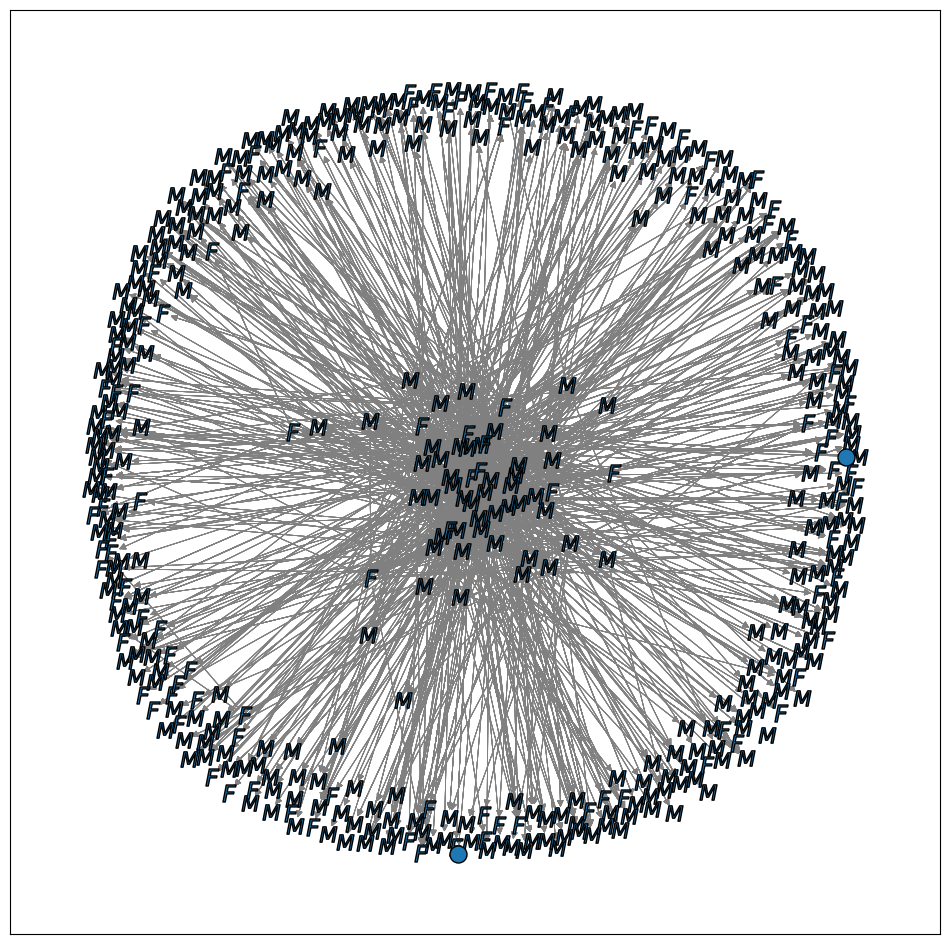

In [ ]:
fig, ax = plt.subplots(nrows=1, figsize=(12, 12), )#dpi=300)
pos = nx.spring_layout(grafo_defesas, seed=42, k=.5)
for gender in nodes_lists.keys():
    nodes_2_plot = nodes_lists[gender]
    gender_marker = "o"
    if gender == "Feminino":
        gender_marker = "$F$"
    elif gender == "Masculino":
        gender_marker = "$M$"
    nx.draw_networkx(
        grafo_defesas,
        pos=pos,
        node_size=150,
        nodelist=nodes_2_plot,
        # node_color=["red" if G.degree(v) == 0 else "skyblue" for v in G.nodes],
        node_shape = gender_marker,
        edge_color="gray", width=.55,
        edgecolors="k", linewidths=1,
        with_labels=False,
        ax=ax
    )

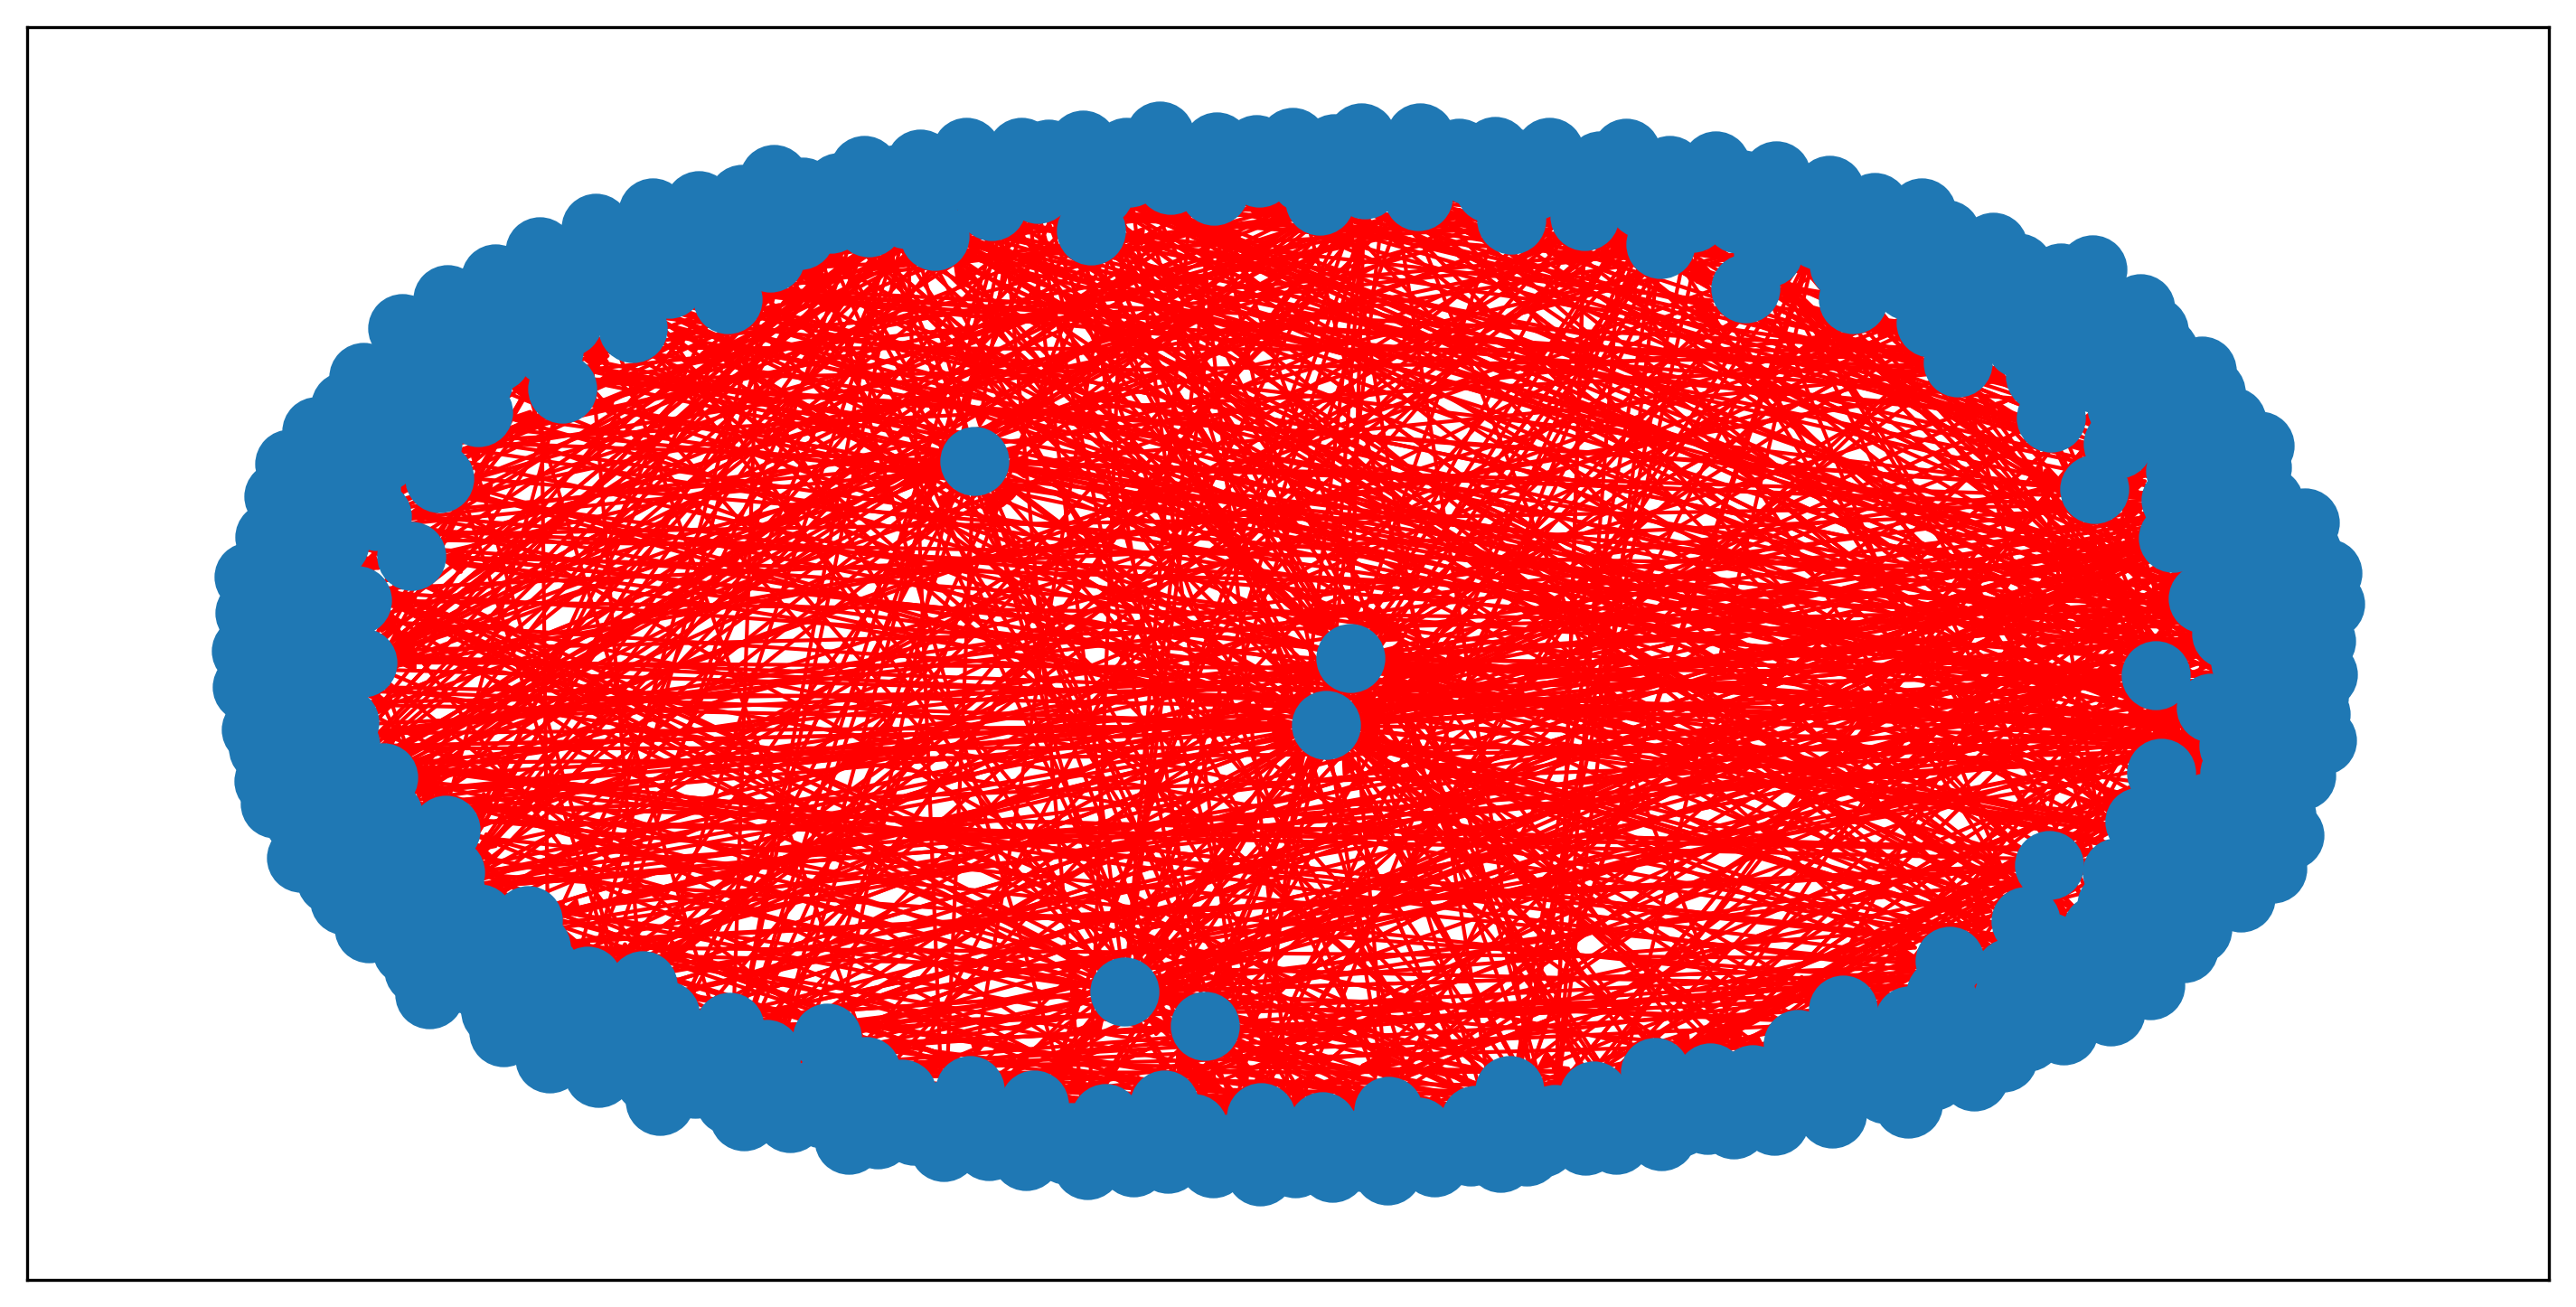

In [9]:
fig, ax = plt.subplots(nrows=1, figsize=(12, 6), dpi=300)
pos = nx.spring_layout(grafo_defesas, k=2, seed = 1931)

# nx.draw(grafo_defesas, with_labels=False, font_weight='bold', pos=pos)
nx.draw_networkx_nodes(grafo_defesas, pos=pos)
nx.draw_networkx_edges(grafo_defesas, pos=pos, width=edge_widths, edge_color=edge_colors)
plt.show()

In [10]:
grafo_defesas.nodes['0000-0002-6540-8686']

{'nome': 'Paulo de Geus',
 'filiacao': 'University of Campinas',
 'orcid': '0000-0002-6540-8686',
 'genero': 'Masculino'}

In [11]:
grafo_defesas.in_degree()

InDegreeView({'0000-0002-6540-8686': 3, '0000-0003-4869-5190': 7, '0000-0001-5685-8004': 9, '0000-0002-2914-5380': 5, '0000-0001-5201-1244': 8, '0000-0003-2046-602X': 3, '0000-0002-8856-194X': 9, '0000-0002-1067-6421': 7, '0000-0002-1180-2637': 14, '0000-0002-4830-5298': 7, '0000-0003-4549-7105': 3, '0000-0003-4290-6508': 4, '0000-0003-3333-6822': 3, '0000-0003-1908-4753': 8, '0000-0002-6023-5982': 14, '0000-0002-5945-0845': 6, '0000-0002-7002-875X': 9, '0000-0002-1914-5790': 1, '0000-0002-3891-1593': 3, '0000-0002-3823-8941': 8, '0000-0002-8803-0401': 10, '0000-0001-7878-4990': 5, '0000-0001-9772-263X': 15, '0000-0002-3159-4839': 4, '0000-0002-6731-1482': 5, '0000-0002-9539-6874': 9, '0000-0001-8923-0432': 1, '0000-0003-4462-3325': 8, '0000-0001-5015-2131': 5, '0000-0001-8309-6367': 9, '0000-0001-9174-2816': 2, '0000-0003-0683-7672': 4, '0000-0001-6030-2682': 10, '0000-0002-9529-4253': 3, '0000-0003-0125-630X': 19, '0000-0002-1756-4852': 11, '0000-0002-4236-8212': 5, '0000-0003-4237-4

In [12]:
node_shape = []
for v in grafo_defesas.nodes:
    # genero = data
    node_shape.append("<" if grafo_defesas.nodes[v]["genero"] == "Masculine" else ">")
    # print(v)
    # print(grafo_defesas.nodes[v]["genero"])
    # break

### Gráfico log-log com graus de saída (orientação->avaliação)

In [67]:
degree_sequence = [d for _, d in grafo_defesas.out_degree()]  # list of degrees
gender_sequence = ["<" if grafo_defesas.nodes[v]["genero"] == "Masculino" else ">" for v, _ in grafo_defesas.out_degree()]  # list of degrees
degree_count = collections.Counter(degree_sequence)
deg, cnt = zip(*sorted(degree_count.items()))
# _, shape = zip(*sorted(node_shape.items()))

In [68]:
degrees = np.array(degree_sequence)
kmin = 1  # or choose based on inspection
filtered = degrees[degrees > kmin]
n = len(filtered)

alpha = 1 + n / np.sum(np.log(filtered / (kmin - 0.5)))
print("alpha =", alpha)

alpha = 1.239509998436153


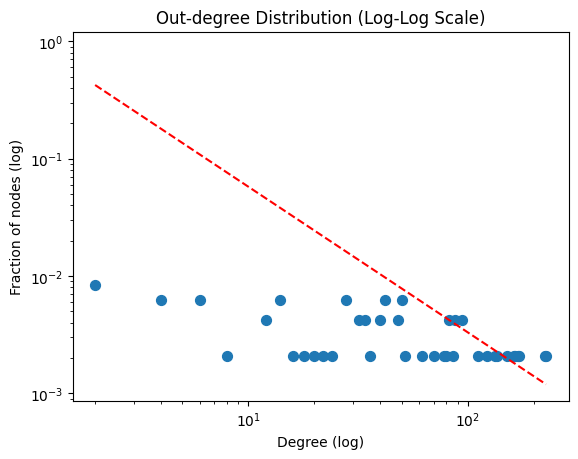

In [69]:
fig, ax = plt.subplots()
for deg, cnt in sorted(degree_count.items()):
    ax.scatter(deg, cnt/len(grafo_defesas), s=50, color="#1f78b4")
# alpha = 2.5  # for example
x = np.logspace(np.log10(min(filtered)), np.log10(max(filtered)), 100)
y = x ** (-alpha)  # diagonal with slope -alpha
# y *= counts[0] / y[0]  # scale it roughly to the first point

plt.plot(x, y, 'r--', label=f'slope = -{alpha:.2f}')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree (log)")
plt.ylabel("Fraction of nodes (log)")
plt.title("Out-degree Distribution (Log-Log Scale)")
# plt.show()
plt.show()

### Gráfico log-log com graus de entrada (avaliação<-orientação)

In [70]:
degree_sequence = [d for _, d in grafo_defesas.in_degree()]  # list of degrees
gender_sequence = ["<" if grafo_defesas.nodes[v]["genero"] == "Masculino" else ">" for v, _ in grafo_defesas.out_degree()]  # list of degrees
degree_count = collections.Counter(degree_sequence)
deg, cnt = zip(*sorted(degree_count.items()))
# _, shape = zip(*sorted(node_shape.items()))

In [71]:
degrees = np.array(degree_sequence)
kmin = 1  # or choose based on inspection
filtered = degrees[degrees > kmin]
n = len(filtered)

alpha = 1 + n / np.sum(np.log(filtered / (kmin - 0.5)))
print("alpha =", alpha)

alpha = 1.4607636849568895


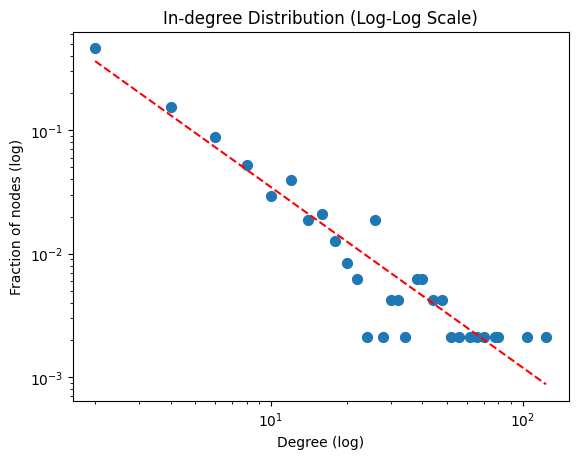

In [ ]:
fig, ax = plt.subplots()
for deg, cnt in sorted(degree_count.items()):
    ax.scatter(deg, cnt/len(grafo_defesas), s=50, color="#1f78b4")
x = np.logspace(np.log10(min(filtered)), np.log10(max(filtered)), 100)
y = x ** (-alpha)  # diagonal with slope -alpha
# y *= counts[0] / y[0]  # scale it roughly to the first point

plt.plot(x, y, 'r--', label=f'slope = -{alpha:.2f}')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree (log)")
plt.ylabel("Fraction of nodes (log)")
plt.title("In-degree Distribution (Log-Log Scale)")
# plt.show()
plt.show()

In [73]:
y

array([0.36330077, 0.34183713, 0.32164156, 0.30263913, 0.28475936,
       0.26793591, 0.25210639, 0.23721206, 0.22319769, 0.21001128,
       0.19760391, 0.18592957, 0.17494494, 0.16460928, 0.15488424,
       0.14573375, 0.13712387, 0.12902266, 0.12140006, 0.11422781,
       0.10747928, 0.10112946, 0.09515478, 0.08953308, 0.08424351,
       0.07926644, 0.07458342, 0.07017707, 0.06603104, 0.06212996,
       0.05845935, 0.0550056 , 0.0517559 , 0.04869818, 0.04582112,
       0.04311403, 0.04056687, 0.0381702 , 0.03591512, 0.03379328,
       0.03179678, 0.02991825, 0.02815069, 0.02648756, 0.02492269,
       0.02345027, 0.02206484, 0.02076126, 0.01953469, 0.01838059,
       0.01729468, 0.01627291, 0.01531152, 0.01440692, 0.01355577,
       0.0127549 , 0.01200135, 0.01129231, 0.01062517, 0.00999744,
       0.00940679, 0.00885105, 0.00832813, 0.00783611, 0.00737315,
       0.00693755, 0.00652768, 0.00614203, 0.00577916, 0.00543773,
       0.00511648, 0.0048142 , 0.00452978, 0.00426216, 0.00401

### Gráfico log-log com graus de entrada e saída

In [29]:
degree_sequence = [d for _, d in grafo_defesas.degree()]  # list of degrees
gender_sequence = ["<" if grafo_defesas.nodes[v]["genero"] == "Masculino" else ">" for v, _ in grafo_defesas.out_degree()]  # list of degrees
degree_count = collections.Counter(degree_sequence)
deg, cnt = zip(*sorted(degree_count.items()))
# _, shape = zip(*sorted(node_shape.items()))

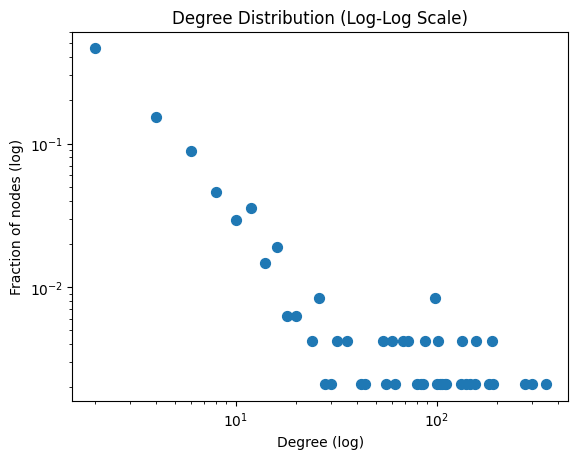

In [30]:
fig, ax = plt.subplots()
for deg, cnt in sorted(degree_count.items()):
    ax.scatter(deg, cnt/len(grafo_defesas), s=50, color="#1f78b4")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree (log)")
plt.ylabel("Fraction of nodes (log)")
plt.title("Degree Distribution (Log-Log Scale)")
# plt.show()
plt.show()